<h1 style="font-size: 40px; margin-bottom: 0px;">1.1 Quick review and Python data visualization (I)</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 700px;"></hr>

Welcome to MCB201B! As you've all had a little bit of practice now navigating your Biology Hub server and learning the basics of Python from MCB201A, we'll start off with a quick review of the things that you learned in Experiment 17, and then we'll expand some more on that by working through how we can use Python to streamline our analysis workflow. Towards the 2nd half of today's lesson, we'll then begin learning how we can use Python to visualize our data. 

The overall structure of lab sessions will be slightly different than in MCB201A. Here, we'll have a mix of guided lessons where you follow along through some Python demonstrations, small in-class exercises that you'll have time to work on, and slightly more challenging exercises that will encompass more of what you've learned and give you the opportunity to apply it to situations you might encounter.

The pace of the lab sessions may deviate from the schedule depending on the rate in which we cover the material for each lesson.

Don't forget that if at anytime, you need to redownload the original version of a notebook for this class, you can simply pull the GitHub repo for this class again, and you'll have the original version again (as well as your copy that you were working on).

<strong>Learning objectives:</strong>
<ul>
    <li>Review data types and its application for control flow</li>
    <li>Review of Python DataFrames and importing your data</li>
    <li>Practice navigating directories while working in a Python notebook</li>
    <li>Learn how to load in multiple files for streamlined processing</li>
    <li>Set up a simple workflow to analyze multiple files at once</li>
    <li>Learn basic data visualization in Python</li>
</ul>

<h2>Import Packages</h2>

Like with MCB201A, we'll have towards the top of our notebook, a code cell where we import all the packages that we'll need for the day's lesson.
Packages that we'll use today are:
<ul>
    <li><code>numpy</code> - to work with numbers and arrays in Python</li>
    <li><code>pandas</code> - to facilitate data processing and analysis with DataFrames</li>
    <li><code>matplotlib.pyplot</code> - for data visualization</li>
    <li><code>os</code> - to perform operating system functions in Python</li>
</ul>

In [2]:
#This set of lines imports the packages that we'll use in today's notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [6]:
#We can also take a look at the packages and functions that we imported by simply calling them up by their name
np.array

#Can see that we call up the numpy package with np, followed by a period, and then the array function
#If we want to then use this function, we'll use np.array() with arguments in the parentheses
#and each argument will be separated by a comma

<function numpy.array>

<h1 style="font-size: 40px; margin-bottom: 0px;">Common data types</h1>
<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

Recall that Python is an object-oriented programming language, and objects have three properties:
<ul>
    <li>Identity - the "address" to find the object in memory that can be accessed via <code>id()</code></li>
    <li>Value - the data or information contained within that object; can be mutable or immutable</li>
    <li>Data type - defines what operations are possible with/using that object and can be accessed via <code>type()</code></li>
</ul>

We can play around with that below for a quick review:

In [14]:
#For example, we can just type some random data here and play around to see
#If we wanted, we can generate a string 'Liebchen'
#Then we can check Liebchen's address via the id() function
print(id('Liebchen'))

#And we can also take a look at the data type using the type() function
print(id('Victor'))

132147631990384
132147632037232


In [17]:
#Can see in this example here, we have two different strings
#Each one will have its own address since they're different objects
print(type('Liebchen'))
print(type('Victor'))

<class 'str'>
<class 'str'>


<h2>Variables</h2>

We can tell Python to "save" our object, so that it knows to hold onto its location in memory and not override it. We do this by assigning our object to a variable, which acts as a pointer that tells Python where to find the object again.

In [18]:
#We can give that a quick test here also for review of Exp 17 stuff
#First we'll assign the object 'Liebchen' to a variable using the assignment operator (the single equals sign)
cat = 'Liebchen'

In [20]:
#Then we can pull up the id for the object and the variable and compare them using a conditional statement
#In this case, the conditional statement uses a double equals sign
#This then denotes that we're creating a conditional statement checking whether two things are the same
id(cat) == id('Liebchen')

#This will then output a boolean, either True or False

True

<h2>Data types</h2>

Data types determine what we can and can't do with an object, and in MCB201A, we covered some common ones including:

<ul>
    <li>strings - also abbreviated as str</li>
    <li>integers - also abbreviated as int</li>
    <li>floats - which are representations of decimal numbers</li>
    <li>booleans - which represent truth values and can be also represnted by <code>0</code> and <code>1</code> for <code>False</code> and <code>True</code>, respectively</li>
</ul>

In [23]:
#We can just quickly  use the type() function to look through some data types
print(type('Liebchen'))
print(type(100))
print(type(1.))

<class 'str'>
<class 'int'>
<class 'float'>


In [26]:
#We can see that although 1 and 1. are different data types,
#They are understood to be the same mathematically
1 == 1.

True

Recall from MCB201A that you also learned about compound data types, which rather than holding a single value like an integer or float, it instead can hold mulitple objects. 

<ul>
    <li>list - denoted by <code>&lbrack; &rbrack;</code></li>
    <li>array - a compound data type from the numpy package</li>
    <li>set - denoted by <code>{ }</code></li>
    <li>dictionary - also denoted by <code>{ }</code>, but contains key:value pairs</li>
    <li>tuple - denoted by <code>( )</code></li>
</ul>

And remember that each compound data type has slightly different properties which affect what we can use them for and what operations we can perform on them.

<h1 style="font-size: 40px; margin-bottom: 0px;">Control flow</h1>
<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

While the standard sequence of code execution is line by line from the first line at the top of the file to the last line at the bottom of the file, recall that you can make use of keyword to control the sequence and conditions under which specific blocks/lines of code are executed.

We can set conditions using if, if-else, and if-elif-else statements to instruct Python to execute certain blocks of code only when defined conditions are met.

For this quick review, we can just make use of a random integer generator that we've used previously <code>np.random.randint()</code>. <a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html" rel="noopener noreferrer"><u>Documentation for <code>np.random.randint()</code> can be found here.</u></a>

In [40]:
#Here, we'll set up a random integer generator
Liebchen = np.random.randint(100)
#Each time you run the function, it'll generate a new random integer up to a max value of 100

#We can check to see what random integer got generated by the function
print(Liebchen)

#Then we can set up an if-else statement to control the execution of code
if Liebchen > 50:
    print('MEOW!!!')
else:
    print('meow...')

5
meow...


We can also define blocks of code as functions that we can later call up. So while these blocks of code aren't executed when they're defined, they can be invoked later in a file or even in another file (recall: modules and packages).

Functions are defined by the keyword <code>def</code>, and can be then invoked by using the function's defined name. When invoking a function, you can pass it arguments, which will then change how the function will perform its defined task.

In [49]:
#Here, we're reviewing how to set up a function
#In this case, the function makes use of the same setup as the if-else example above
#We'll first name our function and set up the parameters it will need to run
def catfood(big_meow, small_meow, upper_limit):
    """
    Name of function is catfood
    So we can execute the function by calling up its name. 
    Not unlike how we call up functions from packages we imported.

    First parameter is big_meow
    Second parameter is small_meow
    Third parameter is upper_limit

    Note how each is separated by a comma.
    There is no default value to the parameters,
    so we'll need to provide it with three arguments in order to run properly.
    """

    #Can see here that our upper_limit parameter is used as a variable in our code block
    Liebchen = np.random.randint(upper_limit)
    #So whatever argument we use,
    #it'll determine the upper limit of the random integer generator function

    #This then outputs the random integer that was generated
    print(Liebchen)

    #Our if-else statement
    if Liebchen > 50:
        #Our big_meow parameter is used here as a variable
        #Outputs what we have Liebchen say when the random integer is > 50
        print(big_meow)
    else:
        #Our small_meow parameter is used here as a variable
        #Outputs what we have Liebchen say when the random integer is not > 50
        print(small_meow)

#You'll want to note how basically parameters are the variables within functions,
#so if you have a parameter that does not have a default value,
#you'll run into an undefined variable error when trying to execute your function.

Now that we defined our function, we can later on call it up, resulting in those lines of code getting executed.

In [50]:
#Here, we're testing out our function
#We can explicitly pass arguments to each parameter (aka assign objects to variables)
catfood(upper_limit=150, big_meow='MEOWWWWW!!!!', small_meow='meow.')

#Or we can do it implicitly based on the position of the parameter when we first set up our function
# catfood('MEOWWWW!!!!', 'meow.', 150)

71
MEOWWWWW!!!!


In the previous example, we simply had our function print out what the result was, but we can also have our function perform some operation and then return to us the output of that operation by using the <code>return</code> keyword.

In [59]:
#If we want a usable output from our function,
#we can't use the print() function
#Instead, we need to have it return to us the object(s) we want to use outside of the function
def mathcat(x, y, z):
    return x * y * z

Now let's give the function that we just defined a try.

In [60]:
mathcat(1, 2, 3)

6

Compare this to if we used the <code>print()</code> function instead.

In [61]:
def printcat(x, y, z):
    print(x*y*z)

In [63]:
printcat(1, 2, 3) + 1

#Can see here that we run into an issue if we want to use the output for other things
#Because print() doesn't generate a usable object type for us to use outside of the function
#so we need to use the return keyword instead of the print() function.

6


TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'

While it may look the same in terms of what we see in the output, you can see that the output from <code>print()</code> isn't really a usable output that we can then use later on in our code. What <code>print()</code> is doing is outputting the value of the variable in the standard output, whereas <code>return</code> will return the object itself.

The other method of controlling the sequence of code execution is using for-loops, which we will make use of today. Recall from MCB201A that for-loops iterate through a given compound data type to repeatedly perform a set operation. For the type of analyses that we'll be doing, we'll be setting up our for-loops with either lists or arrays. 

Let's do a quick review of for-loops and then expand on how we can set them up for the type of analysis that we'll be doing today.

For our set-ups, we'll make use of a Python range constructor <code>range()</code>, which lets us quickly generate a sequence of numbers comprised of values in a defined range and with a set step-size between values. <a href="https://docs.python.org/3/library/functions.html#func-range" rel="noopener noreferrer"><u>Documentation for <code>range()</code> can be found here.</u></a>

In [66]:
#Here, we're reviewing how to set up for-loops like we did in Exp 17
for i in range(0, 10):
    print(i**2)

0
1
4
9
16
25
36
49
64
81


You can see in the example that we again made use of the <code>print()</code> function to output the value of each object as we iterated through our list. Like with functions, this type of output from our for-loop isn't the most helpful if we wanted to make use of outputs from our for-loop.

Now let's see if that output is something usable that we can perform further operations on.

In [67]:
for i in range(0, 5):
    print(i + 4)

4
5
6
7
8


In [72]:
#We'll need to set up a compound data type to hold all the outputs of our for-loop
#In this example here, we can first initialize an empty list and assign it to ludwig
#An empty list is denoted by just [] without anything inside
ludwig = []

#Then we can set up our for-loop
for i in range(0, 5):
    #We can then perform some operation and append the output into our empty list
    ludwig.append(i + 4)
    #This will then "store" the output into our list
    #And each iteration will add a new output to the end of the list

#Can see we can then use this output
ludwig + [9]
#In this case, we're adding on more things to the ludwig list object

[4, 5, 6, 7, 8, 9]

In [76]:
#If we wanted to perform mathematical operations on the output
#We can then instead intialize an array of zeros
#Recall that numpy arrays are different from lists
#We can perform math operations on all elements of a numpy array easily
ludwig = np.zeros(10)
#Here, we've just initialized an array of zeros using the np.zeros() function
#The 10 argument we passed to the function sets the dimensions
#In this case, it is a 1-dimensional array of a length 10.

#Then we can set up our for-loop
for i in range(0, 10):
    #keep in mind the syntax here
    #Because arrays are already a defined size, we need to specify the position
    #And then assign the object we want to that position
    ludwig[i] = i + 4

    #ludwig[i] will pull out positions 0 - 9 with each iteration of the for-loop
    #because the variable i will be assigned values in the range(0, 10)
    #And then we'll assign the results of the operation i + 4 to that position

    #So when i=0, we'll take ludwig[0] and assign it the value 0 + 4, which is 4.
    #Next, when i=1, we'll take ludwig[1] and assign it the value 1 + 4, which is 5.
    #and so on until the end of the range.

#Here, you can see that we can perform mathematical operations on the array
#Which then will perform that operation on each element in the array
ludwig**2
#So we've just calculated the square of each element, as you can see in the output below

array([ 16.,  25.,  36.,  49.,  64.,  81., 100., 121., 144., 169.])

<h1 style="font-size: 40px; margin-bottom: 0px;">DataFrames and importing data</h1>
<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

When we're working with our own data, we'll more often than not be using the pandas package in order work with our data as DataFrames. This data type is intuitively more similar to Excel or Google Sheets and provides us with a lot of functionality for data processing. DataFrames share features with the other compound data types that we've covered, and that allows us to work with DataFrames as if they were lists, sets, and/or dictionaries.

Recall that there's a bunch of ways that we can set up a DataFrame using different compound data types, whether that is with lists, arrays, dictionaries, or Series. For this quick review, we'll just quickly set up a few DataFrames using different data types.

In [79]:
#Here, we're using the DataFrame function within the pandas package
#And providing it with a 2-dimensional list
pd.DataFrame(
    [[0,1], [10, 100]],
)

,0,1
0,0,1
1,10,100


In [83]:
#the DataFrame function can take a lot of different objects and turn them into a DataFrame
#In this example here, we pass it a 2D array of random integers
pd.DataFrame(
    np.random.rand(3,3),
)

,0,1,2
0,0.568712,0.999178,0.690718
1,0.430244,0.814543,0.435884
2,0.118609,0.244790,0.237537


In [84]:
#We can also pass it a dictionary.
#It'll then use the keys as column labels
#and the values associated with those keys will then populate the rows for that column
pd.DataFrame(
    {
        'Tony': [1, 2, 3],
        'Victor': [2, 4, 6],
        'Liebchen': [3, 6, 9],
    },
)

,Tony,Victor,Liebchen
0,1,2,3
1,2,4,6
2,3,6,9


<h2>Retrieving data from a DataFrame</h2>

Recall from MCB201A that we can retrieve things from a DataFrame by making use of either slice notation, dictionary notation, or specific locators <code>.loc[]</code> or <code>.iloc[]</code>, which lets us pull values based on index position or key(s).

Just as a quick refresher, lets assign the last DataFrame from the above examples to retrieve values from.

In [91]:
#Recall from Exp 17, you can retrieve values from a DataFrame in various ways
#First, we'll set up a DataFrame and assign it to a variable to easily call it back up
jack_cats = pd.DataFrame(
    {
        'Tony': [1, 2, 3],
        'Victor': [2, 4, 6],
        'Liebchen': [3, 6, 9],
    },
)

jack_cats

,Tony,Victor,Liebchen
0,1,2,3
1,2,4,6
2,3,6,9


Let's then rename the index values (what the rows' keys are) using the <code>pd.DataFrame.rename()</code> function. <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.rename()</code> can be found here.</code>

In [94]:
#We can rename the indices as well for this example
jack_cats.rename(
    index={
        0: 'tuna',
        1: 'salmon',
        2: 'ahi',
    },
    inplace=True,
)

#Keep in mind that this is one way to rename indices, but there are other ways as well.

In [104]:
jack_cats

,Tony,Victor,Liebchen
tuna,1,2,3
salmon,2,4,6
ahi,3,6,9


In [113]:
#We can pull out values in different ways

#Using dictionary notation, we can pull out columns by their labels
# jack_cats['Tony']
#This will pull out the Tony column


#We can chain it to pull out a single cell
# jack_cats['Tony']['salmon']
#This will pull out the Tony column and then pull out the salmon row
#So we get the object that is at the intersection of Tony and salmon, which is 2

#We can also use .loc and .iloc as well
# jack_cats.loc['salmon', 'Tony']
#Keep in mind that you provide .loc with two dimensions separated by a comma
#In the above, the row is specified first, and then followed by the column.
#So we get the same result as jack_cats['Tony']['salmon']

#We can also pull out a full row or a full column using .loc
# jack_cats.loc['salmon', :]
#In this case, we're pulling out the salmon row
#And then with the colon : we specify that we want all the columns (Tony, Victor, Liebchen)

# jack_cats.loc[:, 'Tony']
#We're now pulling the Tony column, and all the rows within it
#The first dimension is denoted with a colon, indicating we want all the rows
#The second dimension is 'Tony' indicating we want the Tony column.

#Can do the same thing with .iloc
#But the key difference here is that we provide it with index positions not label names
jack_cats.iloc[1, 0]
#So here, we're pulling out the position 1 row (aka 2nd row - salmon)
#And we're pulling out the position 0 column (aka the 1st column - Tony)
#So this gets us the object at the intersection of the salmon row and the Tony column, which is 2
#So in terms of the output, we get the same thing as jack_cats.loc['salmon', 'Tony']
#but we're just using a different method

2

<h2>Importing data from a DataFrame</h2>

We have some sample data that we'll make use of for our guided exercises, and then you'll work on some independent exercises building on what you've learned so far. For this guided portion, we'll use pandas to import a sample dataset into our notebook as a DataFrame.

You'll be able to find the example data in this week's directory in the <code>data</code> subdirectory and then in the <code>example</code> subdirectory.

To do this, we'll make use of the <code>pd.read_csv()</code> function. <a href="https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html" rel="noopener noreferrer"><u>Documentation for <code>pd.read_csv()</code><code> can be found here.</u></a>

In [129]:
#Often, we won't be manually inputting our data into Python
#Instead, we'll have some data table in the form of a csv or similar file type
#So all we need to do is import that data table into Python as a DataFrame
#We do that by making use of pd.read_csv()
sample_1 = pd.read_csv(
    './data/example/sample_1.csv'
)
#At it's simplest, all we need to do is specify the file that we want to open using its file path

Now let's do a quick sanity check to make sure that it imported properly.

In [125]:
#We can always do a quick sanity check
#We can output the full contents of a table with the .style 
#Basically just outputs the table for us in a HTML spreadsheet like format
sample_1.style

,Unnamed: 0,0,1,2,3,4,5
0,0,0.948847,0.900984,0.870761,0.587481,0.301050,0.625124
1,1,0.050425,0.883720,0.900340,0.321184,0.766579,0.892876


It looks like the sample dataset has an extra column in the front that denotes the index position, so we can use the <code>pd.DataFrame.drop()</code> function to get rid of the extra column. <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.drop()</code> can be found here.</u></a>

We can also adjust how we set up our <code>pd.read_csv()</code> function as well.

In [130]:
#If we ever need to drop rows, we can use the .drop() function
#In terms of the syntax, we specify that DataFrame we want to operate on, and then it's followed by .drop()
#with arguments passed within the parentheses
sample_1.drop(
    columns='Unnamed: 0',
    inplace=True,
)
#The inplace=True argument then tells Python to perform this operation on the object directly
#If we insead have inplace=False (which is the default value),
#Then the function will return a copy of the DataFrame with the specified part dropped from it
sample_1

,0,1,2,3,4,5
0,0.948847,0.900984,0.870761,0.587481,0.301050,0.625124
1,0.050425,0.883720,0.900340,0.321184,0.766579,0.892876


In [127]:
sample_1

,0,1,2,3,4,5
0,0.948847,0.900984,0.870761,0.587481,0.301050,0.625124
1,0.050425,0.883720,0.900340,0.321184,0.766579,0.892876


In [133]:
#We can also upon import specify what column we want to use as the index labels
#This conveniently lets us then use the 'Unnamed: 0' column as the index labels, effectively dropping it
sample_1 = pd.read_csv(
    './data/example/sample_1.csv',
    index_col=0,
)

In [134]:
sample_1

,0,1,2,3,4,5
0,0.948847,0.900984,0.870761,0.587481,0.301050,0.625124
1,0.050425,0.883720,0.900340,0.321184,0.766579,0.892876


<h1 style="font-size: 40px; margin-bottom: 0px;">Operating system functionality in Python</h1>
<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 750px;"></hr>

Recall from MCB201A, there were two ways for us to navigate through our Biology Hub server. The first way was simply using the File Browser UI, which is no different than how we navigate through files on our computers. The other way was through Terminal, where you provided commands to direct your Terminal through your directories. We can also do the same thing in Python, instructing it to go through directories to find files. 

In a way, we've already done this through <code>pd.read_csv()</code>, where we provided Python with a string corresponding to the file path for our .csv file. Python can then navigate through the directories to find our .csv file.

```python
sample_1 = pd.read_csv('./data/example/sample_1.csv')
```

Today, you will learn to make use of the <code>os</code> module in order to perform different oprating system tasks, such as changing directories and pulling files. The <code>os</code> module allows you to find files that you want to pull into Python, so you can load in multiple files at once for analysis. In our case, we will be using functions defined in this module to load in files containing our data.

<h2>Identify current working directory</h2>

First, let's take a look at our current working directory by using the <code>os.getcwd()</code> function. <a href="https://docs.python.org/3/library/os.html#os.getcwd" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>os.getcwd()</code> can be found here.</u></a>

In [135]:
#This function outputs a string that corresponds to the file path to our current working directory
os.getcwd()
#If we output/export/save things out from our notebook without specifying a path,
#then it'll automatically be saved within our current working directory.
#By default, a notebook's current working directory is wherever the notebook file is located

#You can see in this case, our notebook is located in Week_01, so it's current working directory is also Week_01

'/home/jovyan/MCB201B_F2026/Week_01'

You can see that the <code>os.getcwd()</code> function outputs to us the path to our current working directory, and by default, our working directory will be the folder that contains our Python notebook.

But what data type are we getting as an output?

In [136]:
type(os.getcwd())
#Can confirm that our output is a string

str

You can see that we're getting a string data type as an output that contains the file path information to our current working directory. 

<strong><i>Recall from MCB201A the types of operations we can perform on strings. What could we potentially use to modify our string to specify the file path to a subdirectory?</i></strong>

In [141]:
#We can concatenate strings together with the plus operator
os.getcwd() + '/data/example/'

'/home/jovyan/MCB201B_F2026/Week_01/data/example/'

<h2>Change directories</h2>

We can also change what folder our notebook is working in by using the <code>os.chdir()</code> function. <a href="https://docs.python.org/3/library/os.html#os.chdir" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>os.chdir()</code> can be found here.</a></u>

To reduce how much we need to type, we can use the <code>os.getcwd()</code> function to get the file path to this week's directory and just add on the subdirectory information.

In [2]:
#We can change our current working directory of this notebook
#Essentially acts similarly to the cd command in Terminal
os.chdir('data')

In [3]:
#Let's check where we are now
os.getcwd()

#Can see that we're now in the data subdirectory

'/home/jovyan/MCB201B_F2026/Week_01/data'

<strong><i>How can we potentially shorten this further?</i></strong>

In [156]:
#There are various ways we can specify a file path from the full path to much abridged ones

# os.chdir('/home/jovyan/MCB201B_F2026/Week_01/data')
#This is a full file path to the data subdirectory

#If our current working directory is Week_01, then we can shorten this
# os.chdir('./data')
#Recall from Terminal that the . denotes the current directory
#So in our case, the . represents the file path /home/jovyan/MCB201B_F2026/Week_01

#We can shorten it further and just specify the subdirectory within Week_01 since we're already in Week_01
os.chdir('data')

#You'll want to keep in mind that with the shorter methods, you will run into issues when rerunning the code cell
#This is because you've changed your current working directory, and unless data exists within there as well,
#you'll encounter a File not found error

#So sometimes, it can be better to just be explicit and specify the full path depending on how you want to use your code

Now let's see what our current working directory is for our notebook.

In [157]:
os.getcwd()

'/home/jovyan/MCB201B_F2026/Week_01/data'

You should be able to see now that our current working directory has been updated to be the <code>data</code> subdirectory contained within this week's directory.

<h2>Get the names of files and folders in a directory</h2>

Now that we're in a directory that we want to work in, we can take a look at what's containined within it by using the <code>os.listdir()</code> function. <a href="https://docs.python.org/3/library/os.html#os.listdir" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>os.listdir()</code> can be found here.</u></a>

```python
os.listdir()
```

This is functionally similar to the <code>ls</code> command in Terminal that you learned in MCB201A.

In [158]:
os.listdir()
#This function will output to us a list containing the file and folder names within whatever directory we're in
#or whatever directory that we specify

#since we're in the data subdirectory, it'll output a list containing the folders within it
#which is just example and cohort

['example', 'cohort']

You should be able to see that the output contains the folders containing different data files for this week that we'll be analyzing as part of today's lesson. Specifically, the <code>cohort</code> folder and the <code>example</code> folder, as well as a hidden .ipynb_checkpoints folder.

Let's now instead output the files contained within the <code>example</code> subdirectory.

In [159]:
#We can pass it a file path (or just the folder name)
#It'll then output what is within that folder
os.listdir('example')

['.ipynb_checkpoints',
 'sample_9.csv',
 'sample_1.csv',
 'sample_2.csv',
 'sample_4.csv',
 'sample_8.csv',
 'sample_5.csv',
 'sample_6.csv',
 'sample_3.csv',
 'sample_7.csv']

<h3>Sort file names</h3>

What you might have noticed is that we got in our output a list containing all the file names for sample data files we want to analyze, but they are given to us in an arbitrary order. While this isn't super critical for today's analysis, if you run into a situation (like in our later image analyses) where you need the files to be in a specific order, you will need to first sort the file names in Python using the <code>list.sort()</code> function. <a href="https://docs.python.org/3/library/stdtypes.html#list.sort" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>list.sort()</code> can be found here.</u></a>

In [4]:
#The output oftentimes is not sorted in alphanumeric order,
#so we need to sort it using the sort() function

#So first we get our list of file names and then assign it to a variable
file_names = os.listdir('example')

#Then we can sort it
file_names.sort()

#And now you can see that it's sorted in alphanumeric order
file_names

#Some of you might have a .ipynb_checkpoints hidden file
#hidden files have a . at the start of the file name

['.ipynb_checkpoints',
 'sample_1.csv',
 'sample_2.csv',
 'sample_3.csv',
 'sample_4.csv',
 'sample_5.csv',
 'sample_6.csv',
 'sample_7.csv',
 'sample_8.csv',
 'sample_9.csv']

You may also find that your <code>example</code> subdirectory contains a .ipynb_checkpoints hidden folder.

<strong><i>How could you potentially use slice notation to remove it from your list?</i></strong>

In [5]:
#To remove that hidden file, we can simply slice it out with slice notation
#And then reassign it back to the same variable
file_names = file_names[1:]
#Here the file_names[1:] denotes that we are taking a slice of a list from file_names
#starting at position 1 (aka the 2nd element), and the colon with nothing after it denotes that we want everything to the end.
#so [1:] reads as we want everything from position 1 (inclusive) to the last element of the list

In [6]:
file_names
#can see now that we sliced out the .ipynb_checkpoints file

#Another way is to use list.pop(0) to pop out the first element (position 0)
#This performs the operation inplace (aka on the list directly), so you don't need to assign to a variable

#The .pop() function will return whatever was popped out, so if you do assign it to a variable
#the variable will be assigned whatever was removed, so you don't want to reassign to the same variable

['sample_1.csv',
 'sample_2.csv',
 'sample_3.csv',
 'sample_4.csv',
 'sample_5.csv',
 'sample_6.csv',
 'sample_7.csv',
 'sample_8.csv',
 'sample_9.csv']

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #1: Import multiple files for analysis</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

For this exercise, see if you can apply what you've learned to now import the set of sample files into Python.

In [8]:
#We can specify flexible file paths in a variety of ways
#We can add strings together where one is a variable
# os.getcwd() + '/example/' + file_names[0]

#Or we can also make use of an f-string, which is a formatted string
#This let's us use variables within a string
f'./example/{file_names[0]}'
#Anything within the curly brackets will execute as if it were a code cell
#So {file_names[0]} will execeute as if it were a code cell to get the first file name

'./example/sample_1.csv'

In [9]:
#First let's get our file names
file_names = os.listdir('example')

#Then sort them
file_names.sort()

#Then if you have the .ipynb_checkpoints hidden file, you can remove that
file_names = file_names[1:]

#Can do a quick sanity check
# file_names

#In order to hold all the data tables that we're importing,
#we need to initialize a compound data type that can hold the outputs of our for-loop
sample_dataset = []

#Set up our for-loop to loop through our list of file names
for i in file_names: 
    #This for-loop will iterate through the list of file names
    #So the first element ('sample_1.csv') will be assigned to the variable i
    #With each iteration, it'll move on to the next element and assign that to the variable i
    
    #Then we import as a DataFrame
    data = pd.read_csv(
        f'./example/{i}', #For first iteration, the i variable will be replaced with sample_1.csv, so the string will read './example/sample_1.csv'
    )

    #Then we append the DataFrame to our empty list.
    sample_dataset.append(data)

#We can then take a look at our list, which now contains all our DataFrames
sample_dataset

[   Unnamed: 0         0         1         2         3         4         5
 0           0  0.948847  0.900984  0.870761  0.587481  0.301050  0.625124
 1           1  0.050425  0.883720  0.900340  0.321184  0.766579  0.892876,
    Unnamed: 0         0         1         2         3         4         5
 0           0  0.581707  0.362048  0.377234  0.391912  0.391218  0.261659
 1           1  0.159126  0.414900  0.673513  0.905496  0.783815  0.550291,
    Unnamed: 0         0         1         2         3         4         5
 0           0  0.711696  0.257550  0.062503  0.126938  0.956557  0.841019
 1           1  0.184728  0.920615  0.662907  0.116992  0.263741  0.458254,
    Unnamed: 0         0         1         2         3         4         5
 0           0  0.393527  0.069669  0.402857  0.893234  0.197616  0.280778
 1           1  0.759921  0.910135  0.057364  0.505850  0.463253  0.778482,
    Unnamed: 0         0         1         2         3         4         5
 0           0  0.542

We can take a break here, and when we reconvene, we'll go over Exercise 1, and then once everyone is on the same page, we can proceed to Exercise 2.

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #2: Update your DataFrames</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 700px;"></hr>

What you can see in the imported files is that the columns and indices don't provide us with much information on this sample dataset. So for this exercise, return to your code from before and modify it so that the rows indicate the <code>control</code> for index <code>0</code> and the <code>tazko</code> for index <code>1</code>.

In [17]:
#First let's get our file names
file_names = os.listdir('example')

#Then sort them
file_names.sort()

#Then if you have the .ipynb_checkpoints hidden file, you can remove that
file_names = file_names[1:]

#Can do a quick sanity check
# file_names

#In order to hold all the data tables that we're importing,
#we need to initialize a compound data type that can hold the outputs of our for-loop
sample_dataset = []

#Set up our for-loop to loop through our list of file names
for i in file_names: 
    #This for-loop will iterate through the list of file names
    #So the first element ('sample_1.csv') will be assigned to the variable i
    #With each iteration, it'll move on to the next element and assign that to the variable i
    
    #Then we import as a DataFrame
    data = pd.read_csv(
        f'./example/{i}', #For first iteration, the i variable will be replaced with sample_1.csv, so the string will read './example/sample_1.csv'
        index_col=0,
    )

    #We can easily update the index (row) labels by calling up the index attribute
    #And assigning the list containing the labels we want to use
    data.index = ['control', 'tazko']
    #In this case, we want to use 'control' and 'tazko' as our labels
    #So we assign it to data.index
    
    #Then we append the DataFrame to our empty list.
    sample_dataset.append(data)

#We can then take a look at our list, which now contains all our DataFrames
sample_dataset

[                0         1         2         3         4         5
 control  0.948847  0.900984  0.870761  0.587481  0.301050  0.625124
 tazko    0.050425  0.883720  0.900340  0.321184  0.766579  0.892876,
                 0         1         2         3         4         5
 control  0.581707  0.362048  0.377234  0.391912  0.391218  0.261659
 tazko    0.159126  0.414900  0.673513  0.905496  0.783815  0.550291,
                 0         1         2         3         4         5
 control  0.711696  0.257550  0.062503  0.126938  0.956557  0.841019
 tazko    0.184728  0.920615  0.662907  0.116992  0.263741  0.458254,
                 0         1         2         3         4         5
 control  0.393527  0.069669  0.402857  0.893234  0.197616  0.280778
 tazko    0.759921  0.910135  0.057364  0.505850  0.463253  0.778482,
                 0         1         2         3         4         5
 control  0.542810  0.996330  0.514617  0.107398  0.007007  0.338683
 tazko    0.332083  0.451541  

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #3: Calculate the means</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

Let's continue to modify our code from earlier, and this time, we want to now calculate the means for each sample. For this, we can make use of the <code>np.mean()</code> function. <a href="https://numpy.org/doc/stable/reference/generated/numpy.mean.html" rel="noopener noreferrer"><u>Documentation for <code>np.mean()</code> can be found here.</u></a> 

Or we can make use of the <code>pd.DataFrame.mean()</code> function. <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.mean()</code> can be be found here.</u></a>

In [26]:
#The example we went over in class used the pd.DataFrame.mean() function
#The below line basically reads as:
#sample_dataset[0]
###From the sample_dataset list (containing all our DataFrames), pull out the first DataFrame (sample_1 data)
#.mean(axis=1)
###Then calculate the mean of all the values for each row
###This returns both the mean for control and mean for tazko
#liebchen =
###Assign the results of that calculation to the variable liebchen
liebchen = sample_dataset[0].mean(axis=1)

#Now we can pull out the calculated mean using dictionary notation
liebchen['tazko']
#The above line will pull out the mean for tazko row
##Recall that we calculated the mean for our first DataFrame (sample_1 data)

0.6358539985553717

In [30]:
###Taking our same code from before and updating it to then calculate the means###
###We calculated the means for one example in the cell above, so now let's set it up within a for-loop###
###So it'll find the means for all the sample datasets that we've loaded in###

#First let's get our file names
file_names = os.listdir('example')

#Then sort them
file_names.sort()

#Then if you have the .ipynb_checkpoints hidden file, you can remove that
file_names = file_names[1:]

#Can do a quick sanity check
# file_names

#In order to hold all the data tables that we're importing,
#we need to initialize a compound data type that can hold the outputs of our for-loop
# sample_dataset = []
#We don't need the above line of code anymore so it's commented out
#That is because we are no longer just loading in samples and storing them
#We'll load them in one at a time then calculate means before moving on to the next dataset
#This lets us handle both importing our data into our notebook and calculating the means within a single notebook

#We want to hold the means of the controls and the tazko samples in their own lists
mean_control_outputs = []
mean_tazko_outputs = []

#Set up our for-loop to loop through our list of file names
for i in file_names: 
    #This for-loop will iterate through the list of file names
    #So the first element ('sample_1.csv') will be assigned to the variable i
    #With each iteration, it'll move on to the next element and assign that to the variable i
    
    #Then we import as a DataFrame
    data = pd.read_csv(
        f'./example/{i}', #For first iteration, the i variable will be replaced with sample_1.csv, so the string will read './example/sample_1.csv'
        index_col=0,
    )

    #Update row label names
    data.index = ['control', 'tazko']

    #Calculate the means for each dataset along each row
    means = data.mean(
        axis=1,
    )
    #That will give us the control mean and tazko mean

    #We can then pull out the control and tazko means
    #And append it to our list that is set up to hold outputs from our for-loop
    mean_control_outputs.append(means.control)
    mean_tazko_outputs.append(means.tazko)
    
    #Then we append the DataFrame to our empty list.
    # sample_dataset.append(data)
    #We no longer need this because we're now outputting our means instead of just looking at each DataFrame
    
#We can then take a look at our list, which now contains all our DataFrames
# sample_dataset


#We can take a look at our outputs
print(mean_control_outputs, '\n')

print(mean_tazko_outputs)

[0.705707649269891, 0.3942961266837703, 0.49271035733998986, 0.3729469686892019, 0.4178075473392626, 0.6595404558626446, 0.5885066781041228, 0.415438239439016, 0.617943273782089] 

[0.6358539985553717, 0.5811899900012011, 0.4345395867102518, 0.5791675996000406, 0.4216176109288774, 0.6961106571309754, 0.5395635410708114, 0.6176413394257626, 0.2606031294143618]


Before we begin the next set of exercises, let's reconvene to see how everyone's code looks like.

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #4: Process and analyze cohort data</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

For this exercise, we'll be making use of the class raw data file for the MTT assay. The files have been cleaned and should have been pulled into your server along with today's notebook and the example data files. 

While everyone analyzed their own dataset (often in GraphPad/Prism or Excel or Google Sheets), it was for a single biological replicate, and later everyone shared the results of their analysis to get the full class dataset. If you needed to analyze all the class files on your own using Excel, it could take a good chunk of time to be able to process everyone's data. For the MTT assay, each replicate has its own control and background control, so each file requires a bit more processing.

See if you can take what you've learned from today's lesson and the previous set of exercises to import and process the class results from each group's MTT assay. 

You can analyze just the YAP data or just the TAZ data depending on what your group's target gene was. Each file is noted with what the target gene was, so see if you can set up a way to pull just the file names containing that gene (i.e. a conditional statement).

If it helps, you can see if you can set up the code for a single file, and then make adjustments so that it can be incorporated into a for-loop to be used to process multiple files.

In [3]:
#Change into our data directory if needed
os.chdir('data')

In [31]:
#Then here, we pull out files from cohort subdirectory instead of example subdirectory
file_names = os.listdir('./cohort')
#Then we sort the files based on their name
file_names.sort()

#Then we can filter the file names depending on if we want to analyze taz or yap ko data
#This example here compacts a for-loop containing an if statement into a single line,
#where the output is a list containing all elements matching the given condition
#This lets us pull out just taz or just yap ko data based on the file name,
#since the file names are set up to identify them based on either yap or taz in the file name
taz_files = [x for x in file_names if 'taz' in x]
yap_files = [x for x in file_names if 'yap' in x]

#Initialize empty lists to hold outputs from for-loop
mean_corrected_control_absorbances = []
mean_corrected_gene_ko_absorbances = []

#Then we set up our for-loop
for sample_file in yap_files:
    #We can make our for-loop able to take in either yap or taz data
    #Essentially we just prepare a variable gene_ko
    #that will change based on whether we are working with taz or yap data
    #That will then allow us to label our rows accordingly
    if 'taz' in sample_file:
        gene_ko = 'tazko'
    elif 'yap' in sample_file:
        gene_ko = 'yapko'
    else:
        pass

    #Load in our class data for our specified gene ko condition
    data = pd.read_csv(f'./cohort/{sample_file}',
                       index_col=0,
                      )
    #Then rename the row labels
    #Notice how one of the labels is the variable gene_ko
    #This label will change based on what ko condition we're working with
    data.index = ['control', gene_ko, 'background']

    #Then calculate means along each row
    means = data.mean(axis=1)

    #Pull out the mean background to correct absorbance measurements
    mean_bg = means.background

    #We can then subtract the mean background from our DataFrame and reassign it back into the same variable
    #In this case, the usual syntax would be data = data - mean_bg
    #But we can collapse that using substraction assignment operator
    #Which means that we want to take the object on the left, subtract the object on the right,
    #and then reassign back to the variable on the left
    #so we condense data = data - mean_bg into the below
    data -= mean_bg

    #Pull out the means for the control and gene ko rows
    mean_control = means.control
    mean_gene_ko = means[gene_ko]

    #Then append it to their respective list
    mean_corrected_control_absorbances.append(mean_control)
    mean_corrected_gene_ko_absorbances.append(mean_gene_ko)

#Now we can take a look at the output
print(mean_corrected_control_absorbances, '\n')
print(mean_corrected_gene_ko_absorbances)

#We can then normalize to the class control mean value
relative_control = mean_corrected_control_absorbances / np.mean(mean_corrected_control_absorbances)
relative_gene_ko = mean_corrected_gene_ko_absorbances / np.mean(mean_corrected_control_absorbances)

#And we can take another look to see
print(relative_control, '\n')

print(relative_gene_ko)

[0.8130833333333333, 0.5345833333333333, 0.8200833333333333, 0.3901666666666667, 0.7074166666666667] 

[1.3165833333333334, 0.26025000000000004, 0.6705833333333334, 0.3255833333333334, 0.47383333333333333]
[1.24502348 0.81857391 1.25574214 0.59743773 1.08322274] 

[2.01600143 0.39850449 1.02682217 0.49854532 0.72555125]


<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #5: Combine output into single DataFrame</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 950px;"></hr>

We now have two lists, with each list corresponding to the control relative mean absorbances and the other list corresponding to the TAZ KO relative mean absorbaces. For this exercise, see if you can create a new DataFrame containing these outputs with the index labeled accordingly for the two conditions.

In [32]:
#We can set up a DataFrame using our relative mean absorbances
#We combine our two lists into a larger list, so a 2D list
#Then we can pass that to the pd.DataFrame function
#And when we do, we can pass an argument for how we want the row labels to be set
#Here, we set the row labsl to be 'control' and whatever our gene ko condition is
rel_mean_results = pd.DataFrame(
    [relative_control, relative_gene_ko],
    index = ['control', gene_ko],
)

In [33]:
rel_mean_results

,0,1,2,3,4
control,1.245023,0.818574,1.255742,0.597438,1.083223
yapko,2.016001,0.398504,1.026822,0.498545,0.725551


<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #6: Transpose DataFrame</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 650px;"></hr>

Often, DataFrames will be arranged such that each column is a different condition or group. Recall from MCB201A that we can easily transpose our DataFrame, so that way, our columns will indicate the condition rather than the biological replicate.

In [34]:
#We can transpose our DataFrame to orient it in the orientation that plotting functions normally expect it to be in
rel_mean_results = rel_mean_results.T

rel_mean_results

,control,yapko
0,1.245023,2.016001
1,0.818574,0.398504
2,1.255742,1.026822
3,0.597438,0.498545
4,1.083223,0.725551


In [35]:
os.getcwd()

'/home/jovyan/MCB201B_F2026/Week_01/data'

In [36]:
#We can also export our DataFrame for later use in Week 2
rel_mean_results.to_csv(
    'class_mtt_yap_data.csv',
    index=False,
)

Now that we have a DataFrame containing our cohort data, we can use it to learn how to visualiz 

<h1 style="font-size: 40px; margin-bottom: 0px;">Basic data visualization in Python</h1>
<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 750px;"></hr>

For some basic data visualization, we'll first learn how to use <code>matplotlib</code>, which is an extensive Python library containing a lot of different packages and modules that allow us to generate simple graphs to more complex visualizations. It has functions to create any number of plots, and it can be used to create static, animated, and interactive plots. The versatility of <code>matplotlib</code> makes it very helpful when creating publication quality figures.

You can find the documentation of matplotlib <u><a href="https://matplotlib.org/" rel="noopener noreferrer" target="_blank">here</a></u>.

Because it can get confusing at times to figure out how to set up a plot a certain way or what functions are available, a quick Google search can often aid in helping find the right code to get your data to plot the way you want it to (or you can also ask ChatGPT). So don't be afraid to look things up.

<h2>Setting up a bar plot</h2>

To set up a bar plot, you would make use of the <code>plt.bar()</code> function. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html" rel="noopener noreferrer"><u>Documentation for <code>plt.bar()</code> can be found here.</u></a>

We will provide it with two arguments which containes the information to be plotted on two axes. First, we will provide the function with a list containing our sample conditions, and then we provide it with another list which contains the mean relative absorbances. You'll want to be careful to keep in mind that the position within each list matters because the sample condition will be plotted along with a value based the fact that they're in the same position of their respective lists.

In [38]:
#Like we did to pull out row labels using .index,
#we can pull out column labels using .columns
rel_mean_results.columns

Index(['control', 'yapko'], dtype='object')

<BarContainer object of 2 artists>

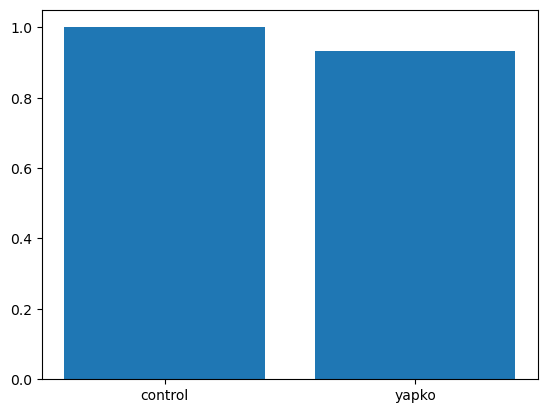

In [39]:
#Then we can set up a simple bar plot with no extra flourishes
plt.bar(
    rel_mean_results.columns,              #we specify the x-axis, which will be our sample conditions
    [np.mean(rel_mean_results.control),    #Then we can pass a list containing the means for our bar heights
     np.mean(rel_mean_results.yapko)])

<h2>Basic formatting for a plot</h2>

We will adjust slightly how we set up our plot, so that we can call up specific attributes of our plot in order to change them to show information that we want the plot to have. For example, looking at our plot currently, you might notice that it's missing the Y-axis label and the X-axis tick marks can be adjusted to not all be entirely lowercase with no spaces.

To set this up, we will make use of the <code>plt.subplots()</code> function. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html" rel="noopener noreferrer"><u>Documentation for <code>plt.subplots()</code> can be found here.</u></a> If you dig into the documentation, you can see that <code>plt.subplots()</code> returns to us two objects. The first object is <code>fig</code> and the second is <code>ax</code>. These two objects specify the layout and the formatting of the figure.

Since the function returns two outputs, we can unpack those two outputs into two separate variables.

```python
fig, ax = plt.subplots()
```

This is a fairly common way of setting up not only single plots but also multiple plots (subplots).

Let's first modify the Y-axis so that it shows the Y-axis label by pulling out the Y-axis label attribute from the <code>ax</code> object that was returned to us by <code>plt.subplots()</code>.

Text(0, 0.5, 'Relative absorbance')

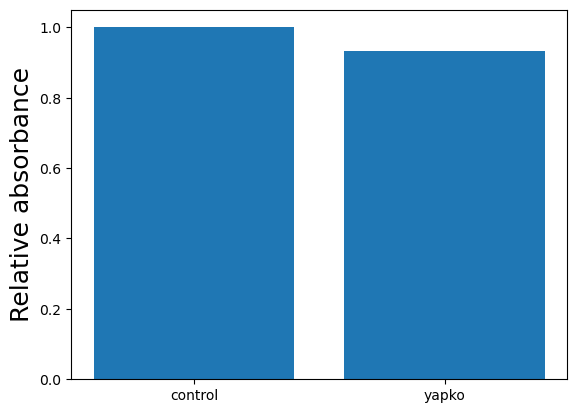

In [47]:
#Set up our figure in the usual way
fig, ax = plt.subplots()

#Then we can plot our bar plot
plt.bar(
    rel_mean_results.columns,
    [np.mean(rel_mean_results.control),
     np.mean(rel_mean_results.yapko)])

#Here, we set the y label by pulling out the set_ylabel method
ax.set_ylabel('Relative absorbance', fontsize=18)

Now let's update the X-tick labels by pulling out attributes to modify from the <code>ax</code> object.

[Text(0, 0, 'Control'), Text(1, 0, '$YAP$ KO')]

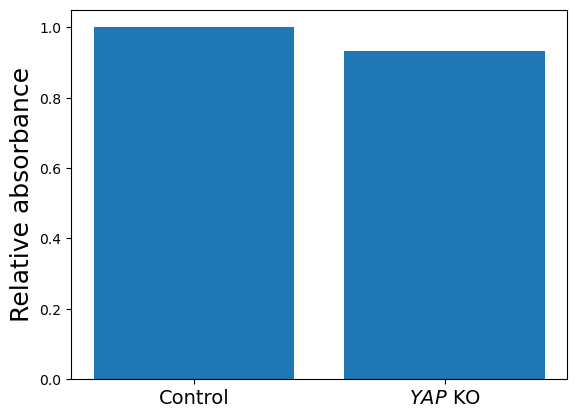

In [51]:
fig, ax = plt.subplots()

plt.bar(
    rel_mean_results.columns,
    [np.mean(rel_mean_results.control),
     np.mean(rel_mean_results.yapko)])

ax.set_ylabel('Relative absorbance', fontsize=18)

#Here we can do the same thing to update our xticks and their labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', '$YAP$ KO'], fontsize=14)

Let's finish by updating the Y-axis tick labels to be more consistent with how we updated the other labels. In this instance, instead of pulling an attribute from <code>ax</code>, we'll use <code>plt.yticks()</code> because it'll allow us to update the tick labels without needing to specify them first.

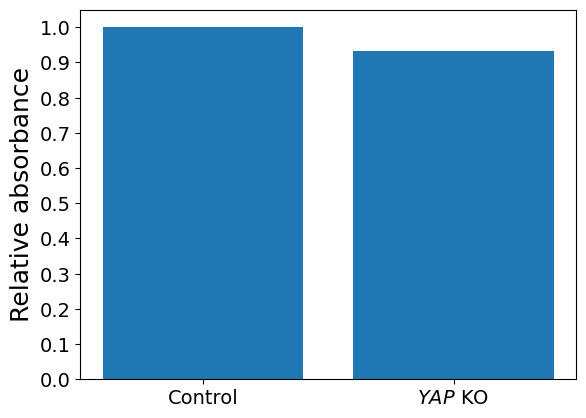

In [64]:
fig, ax = plt.subplots()

plt.bar(
    rel_mean_results.columns,
    [np.mean(rel_mean_results.control),
     np.mean(rel_mean_results.yapko)])

ax.set_ylabel('Relative absorbance', fontsize=18)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', '$YAP$ KO'], fontsize=14)

#We can update our yticks as well
ax.set_yticks(np.arange(0, 1.01, 0.1))
plt.yticks(fontsize=14);